# 第3章 聚类——银行客户细分（K-Means）

## 一、实验简介

本实验围绕 **Credit Card Dataset for Clustering（Kaggle）** 展开，目标是基于客户信用卡使用行为进行无监督分群（Customer Segmentation）。

在银行零售与财富管理场景中，客户分群常用于：

- 差异化营销策略（活动、权益、费率）
- 风险与授信策略分层
- 客户运营与价值提升（留存、复购、交叉销售）

本实验重点关注三个问题：

1. 如何使用 **K-Means** 对客户行为进行自动分群？
2. 如何用 **肘部法（Elbow）** 与 **Silhouette 分数** 选择合理簇数 `k`？
3. 如何把“数学上的簇”转化为“业务可解释的人群画像”（如 `revolvers`、`transactors`）？

## 二、实验目标

- 理解无监督学习与客户分群在银行场景中的应用价值。
- 掌握 K-Means 的训练流程与关键超参数（`n_clusters`、`n_init`、`random_state`）。
- 学会结合肘部法与 Silhouette 分数进行选 `k`。
- 学会输出聚类结果的业务画像，并给出针对性营销建议。

## 三、实验要求

- 使用 Kaggle 的信用卡客户聚类数据集（本地 CSV）。
- 完成数据清洗、特征标准化、K-Means 建模。
- 至少比较 `k=2~10` 的效果，输出肘部图与 Silhouette 曲线。
- 对最终簇做画像分析：规模、行为特征、业务命名与营销建议。

## 四、思考提示

1. 为什么聚类前通常需要做标准化？
2. 为什么不能只看肘部图，不看 Silhouette？
3. 聚类结果在不同随机种子下是否稳定？如何验证？


In [34]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import kagglehub
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
	silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def configure_plot_fonts() -> None:
	"""配置绘图风格与中文字体。"""

	sns.set_theme(style="whitegrid")
	plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
	plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()


## 1. 数据集介绍与读取

本实验使用 Kaggle 常见信用卡客户行为数据集（常见文件名：`CC GENERAL.csv`）。

典型字段包括：

- `BALANCE`：账户当前余额（欠款规模）
- `PURCHASES`：总消费金额（整体消费能力）
- `ONEOFF_PURCHASES`：一次性大额消费金额
- `INSTALLMENTS_PURCHASES`：分期消费金额
- `CASH_ADVANCE`：现金预借金额（通常成本更高）
- `CASH_ADVANCE_FREQUENCY`：现金预借发生频率
- `PURCHASES_FREQUENCY`：消费发生频率（活跃度）
- `PRC_FULL_PAYMENT`：全额还款比例（还款习惯）
- `PAYMENTS`：实际还款金额
- `MINIMUM_PAYMENTS`：最低还款金额
- `CREDIT_LIMIT`：授信额度
- `TENURE`：账户存续月数

从业务角度看，这些变量覆盖了“消费行为、负债行为、还款行为、额度水平”四个核心维度，非常适合做客户细分。

本实验仅使用一个标准缓存文件：

- `data/CC GENERAL.csv`

代码会优先读取本地 `data/CC GENERAL.csv`；若不存在，再通过 `kagglehub` 下载同一数据集并定位同名文件。

In [35]:
DEFAULT_LOCAL_DATA_PATH = Path("data/CC GENERAL.csv")
DEFAULT_KAGGLE_DATASETS = [
	"arjunbhasin2013/ccdata",
]


def _download_from_kagglehub() -> Path:
	"""下载数据集并返回可读取的 CC GENERAL.csv 路径。"""

	for dataset_ref in DEFAULT_KAGGLE_DATASETS:
		download_dir = Path(kagglehub.dataset_download(dataset_ref))
		matches = list(download_dir.rglob(DEFAULT_LOCAL_DATA_PATH.name))
		if matches:
			print(f"已通过 kagglehub 下载数据文件：{matches[0]}")
			return matches[0]

	raise FileNotFoundError("kagglehub 下载完成，但未找到 CC GENERAL.csv。")


def load_credit_card_clustering_data(path: str | Path | None = None) -> pd.DataFrame:
	"""读取信用卡客户聚类数据（本地优先，缺失时自动下载）。"""

	if path is not None:
		csv_path = Path(path)
		if not csv_path.exists():
			raise FileNotFoundError(f"未找到指定数据文件：{csv_path}")
		return pd.read_csv(csv_path)

	if DEFAULT_LOCAL_DATA_PATH.exists():
		print(f"检测到数据文件：{DEFAULT_LOCAL_DATA_PATH}")
		return pd.read_csv(DEFAULT_LOCAL_DATA_PATH)

	downloaded_csv = _download_from_kagglehub()
	return pd.read_csv(downloaded_csv)


df_raw = load_credit_card_clustering_data()
print("原始数据维度：", df_raw.shape)
display(df_raw.head())


检测到数据文件：data\CC GENERAL.csv
原始数据维度： (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 2. 数据概览与质量检查

我们先检查数据类型、缺失值、重复样本，确保后续聚类质量。

这样做的原因是：

- 聚类完全依赖特征距离，脏数据会直接扭曲距离计算；
- 缺失值若不处理，会导致标准化与 K-Means 无法正常运行；
- 重复样本会放大某类客户的权重，影响簇中心位置；
- 在建模前先确认数据质量，能减少“调参但无效”的时间成本。

In [36]:
df = df_raw.copy()

display(df.info())
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
print("缺失率（前 10 列，单位 %）：")
print(missing_ratio.head(10).round(2))

dup_count = df.duplicated().sum()
print(f"\n重复样本数：{dup_count}")


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

None

缺失率（前 10 列，单位 %）：
MINIMUM_PAYMENTS          3.50
CREDIT_LIMIT              0.01
BALANCE                   0.00
CUST_ID                   0.00
BALANCE_FREQUENCY         0.00
PURCHASES                 0.00
CASH_ADVANCE              0.00
PURCHASES_FREQUENCY       0.00
ONEOFF_PURCHASES          0.00
INSTALLMENTS_PURCHASES    0.00
dtype: float64

重复样本数：0


## 3. 数据预处理

处理步骤：

1. 删除仅用于标识的 `CUST_ID`（若存在）
2. 将所有字段转为数值（无法转换的设为缺失）
3. 用中位数填补缺失值
4. 保留可用于聚类的数值特征

为什么要这样处理：

- `CUST_ID` 是身份标识，不代表行为特征，保留会引入噪声；
- 统一数值类型是为了后续距离计算与标准化；
- 中位数对极端值更稳健，适合金融行为数据；
- 常量列没有区分度，保留只会增加计算量而不增加信息。

In [37]:
def prepare_features_for_clustering(df_input: pd.DataFrame) -> pd.DataFrame:
	"""完成聚类前的数据清洗，并返回数值特征矩阵。"""

	df_work = df_input.copy()
	if "CUST_ID" in df_work.columns:
		df_work = df_work.drop(columns=["CUST_ID"])

	for col in df_work.columns:
		df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

	numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()
	df_num = df_work[numeric_cols].copy()
	df_num = df_num.fillna(df_num.median(numeric_only=True))

	# 若存在全空或常量列，可在此剔除，避免对距离计算产生噪声
	non_constant_cols = [c for c in df_num.columns if df_num[c].nunique() > 1]
	df_num = df_num[non_constant_cols]
	return df_num


X = prepare_features_for_clustering(df)
print("预处理后特征维度：", X.shape)
print("用于聚类的字段：")
print(X.columns.tolist())


预处理后特征维度： (8950, 17)
用于聚类的字段：
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## 4. 特征标准化

K-Means 使用欧氏距离，量纲差异会显著影响结果。标准化是必要步骤。

同时，训练/测试拆分时应只在训练集 `fit` 标准化器，再分别 `transform` 训练集与测试集，避免数据泄漏。


In [38]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)

print("训练集形状：", X_train.shape)
print("测试集形状：", X_test.shape)
print("训练集标准化后形状：", X_train_scaled.shape)
print("测试集标准化后形状：", X_test_scaled.shape)


训练集形状： (7160, 17)
测试集形状： (1790, 17)
训练集标准化后形状： (7160, 17)
测试集标准化后形状： (1790, 17)


## 5. 选择最优簇数 k（Elbow + Silhouette）

- **肘部法**：关注 Inertia 的下降速度何时明显变缓（拐点）
- **Silhouette**：衡量簇内紧密度与簇间分离度，越高越好

当两者结论不一致时，需要结合业务可解释性做折中，而不是机械选最大分数。


,k,inertia,silhouette
0,2,102180.286645,0.209658
1,3,89415.008319,0.252161
2,4,79032.062212,0.198686
3,5,73010.177344,0.193252
4,6,67708.617789,0.203046
5,7,63332.203310,0.215835
6,8,59487.141366,0.223021
7,9,55615.061767,0.227321
8,10,52789.790346,0.223994


Silhouette 最优：k=3
肘部法（最大垂距）检测：k=4


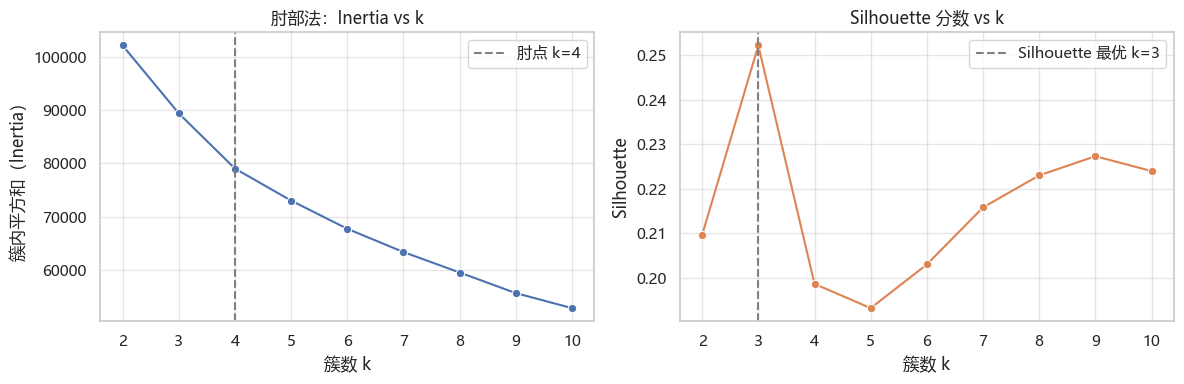

In [39]:
def evaluate_k_candidates(
	X_scaled: np.ndarray,
	k_min: int = 2,
	k_max: int = 10,
	random_state: int = 42,
) -> pd.DataFrame:
	"""计算不同 k 的 Inertia 与 Silhouette 分数。"""

	rows: list[dict[str, float | int]] = []
	for k in range(k_min, k_max + 1):
		km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
		labels = km.fit_predict(X_scaled)
		rows.append(
			{
				"k": k,
				"inertia": km.inertia_,
				"silhouette": silhouette_score(X_scaled, labels),
			}
		)
	return pd.DataFrame(rows)


def detect_elbow_k(k_values: np.ndarray, inertia_values: np.ndarray) -> int:
	"""用“首末点连线最大垂距”方法自动检测肘点。"""

	if len(k_values) < 3:
		raise ValueError("肘部法至少需要 3 个候选 k。")

	x = k_values.astype(float)
	y = inertia_values.astype(float)
	x1, y1 = x[0], y[0]
	x2, y2 = x[-1], y[-1]
	line_norm = float(np.hypot(y2 - y1, x2 - x1))
	if line_norm == 0:
		return int(k_values[0])

	distances: list[float] = []
	for xi, yi in zip(x, y):
		numerator = abs((y2 - y1) * xi - (x2 - x1) * yi + x2 * y1 - y2 * x1)
		dist = numerator / line_norm
		distances.append(float(dist))

	distance_array = np.array(distances, dtype=float)
	distance_array[[0, -1]] = -1.0  # 端点不作为肘点
	return int(k_values[int(np.argmax(distance_array))])


k_eval_df = evaluate_k_candidates(X_train_scaled, k_min=2, k_max=10)
display(k_eval_df)

silhouette_k = int(k_eval_df.loc[k_eval_df["silhouette"].idxmax(), "k"])
elbow_k = detect_elbow_k(k_eval_df["k"].to_numpy(), k_eval_df["inertia"].to_numpy())

print(f"Silhouette 最优：k={silhouette_k}")
print(f"肘部法（最大垂距）检测：k={elbow_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_eval_df, x="k", y="inertia", marker="o", ax=axes[0], color="#4C72B0")
axes[0].axvline(elbow_k, linestyle="--", color="gray", label=f"肘点 k={elbow_k}")
axes[0].set_title("肘部法：Inertia vs k")
axes[0].set_xlabel("簇数 k")
axes[0].set_ylabel("簇内平方和（Inertia）")
axes[0].legend()

sns.lineplot(data=k_eval_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#DD8452")
axes[1].axvline(silhouette_k, linestyle="--", color="gray", label=f"Silhouette 最优 k={silhouette_k}")
axes[1].set_title("Silhouette 分数 vs k")
axes[1].set_xlabel("簇数 k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. 训练最终 K-Means 模型与多 k 测试集对比

在本节中，我们会先比较不同 `k` 在**测试集**上的聚类指标，再确定最终簇数。

评估指标含义：

- `Silhouette`：越高越好，表示簇内更紧凑、簇间更分离。


,k,train_inertia,test_silhouette,rank_silhouette
0,2,102180.286645,0.217275,5.0
1,3,89415.008319,0.235339,1.0
2,4,79032.062212,0.200438,8.0
3,5,73010.177344,0.196278,9.0
4,6,67708.617789,0.204959,7.0
5,7,63332.203310,0.215136,6.0
6,8,59487.141366,0.224715,4.0
7,9,55615.061767,0.227739,2.0
8,10,52789.790346,0.224771,3.0


肘部法建议（第5节）：k=4
测试集 Silhouette 最优：k=3


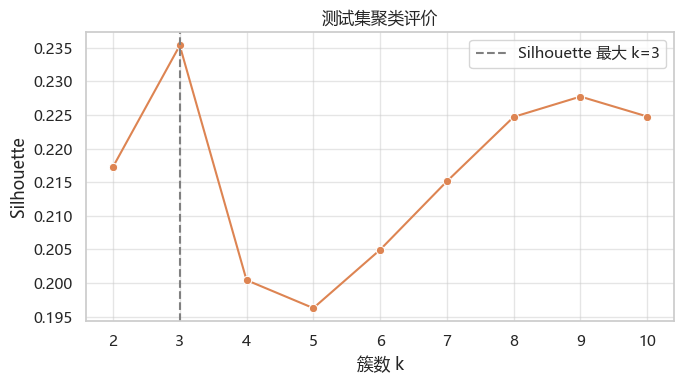

测试集 Silhouette: 0.2353（越高越好）


In [40]:
def evaluate_k_on_test(
	X_train_scaled: np.ndarray,
	X_test_scaled: np.ndarray,
	k_min: int = 2,
	k_max: int = 10,
	random_state: int = 42,
) -> pd.DataFrame:
	"""在训练集拟合、在测试集上比较多 k 的 Silhouette。"""

	rows: list[dict[str, float | int]] = []
	for k in range(k_min, k_max + 1):
		km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
		km.fit(X_train_scaled)
		test_labels = km.predict(X_test_scaled)

		# 若测试集预测结果退化为单簇，则轮廓系数不可计算。
		if np.unique(test_labels).size < 2:
			sil = np.nan
		else:
			sil = silhouette_score(X_test_scaled, test_labels)

		rows.append(
			{
				"k": k,
				"train_inertia": km.inertia_,
				"test_silhouette": sil,
			}
		)

	result = pd.DataFrame(rows)
	result["rank_silhouette"] = result["test_silhouette"].rank(ascending=False, method="min")
	return result


k_test_eval_df = evaluate_k_on_test(X_train_scaled, X_test_scaled, k_min=2, k_max=10)
display(k_test_eval_df)

valid_k_df = k_test_eval_df.dropna(subset=["test_silhouette"])
score_best_k = int(valid_k_df.sort_values(["rank_silhouette", "k"]).iloc[0]["k"])
FINAL_K = score_best_k

print(f"肘部法建议（第5节）：k={elbow_k}")
print(f"测试集 Silhouette 最优：k={score_best_k}")

plt.figure(figsize=(7, 4))
sns.lineplot(data=k_test_eval_df, x="k", y="test_silhouette", marker="o", color="#DD8452")
plt.axvline(FINAL_K, linestyle="--", color="gray", label=f"Silhouette 最大 k={FINAL_K}")
plt.title("测试集聚类评价")
plt.xlabel("簇数 k")
plt.ylabel("Silhouette")
plt.legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
kmeans.fit(X_train_scaled)
train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_scaled)

cluster_labels = kmeans.predict(X_all_scaled)
result_df = X.copy()
result_df["cluster"] = cluster_labels

sil_test = silhouette_score(X_test_scaled, test_labels)

print(f"测试集 Silhouette: {sil_test:.4f}（越高越好）")


## 7. 聚类结果可视化

使用 PCA 将高维特征压缩到二维，仅用于可视化观察簇结构。


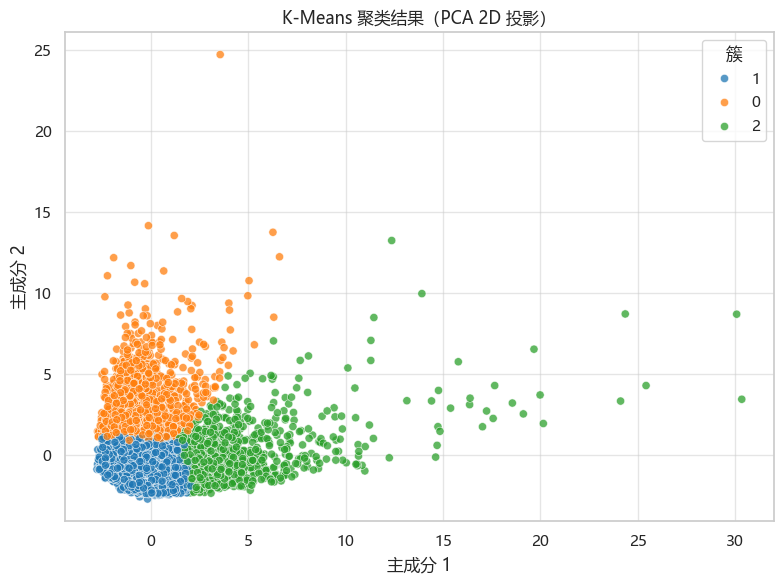

各簇样本规模（文本摘要）：
- cluster 0: 1587 人，占比 17.73%
- cluster 1: 6151 人，占比 68.73%
- cluster 2: 1212 人，占比 13.54%


In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["cluster"] = cluster_labels.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
	data=plot_df,
	x="PC1",
	y="PC2",
	hue="cluster",
	palette="tab10",
	alpha=0.75,
	s=35,
)
plt.title("K-Means 聚类结果（PCA 2D 投影）")
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")
plt.legend(title="簇")
plt.tight_layout()
plt.show()

cluster_size_df = (
	result_df["cluster"]
	.value_counts()
	.sort_index()
	.rename_axis("cluster")
	.reset_index(name="count")
)

print("各簇样本规模（文本摘要）：")
for _, row in cluster_size_df.iterrows():
	ratio = row["count"] / len(result_df)
	print(f"- cluster {int(row['cluster'])}: {int(row['count'])} 人，占比 {ratio:.2%}")


## 8. 客户画像：各簇金融行为特征

我们从两个角度做画像：

1. **原始量纲均值**：便于业务直觉解读
2. **标准化中心热力图**：便于横向比较“高于/低于总体”


,样本数,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,占比
cluster,,,,,,,,,,,,,,,,,,,
0,1587,4007.015382,0.960291,380.893768,247.023094,133.948601,3869.079531,0.231695,0.110184,0.144325,0.447256,12.398866,5.554505,6693.103053,3022.24824,1794.711497,0.033024,11.362949,0.177318
1,6151,800.479295,0.835299,510.397721,257.759972,252.956877,333.298923,0.466519,0.134550,0.345097,0.068594,1.219639,8.707527,3283.933277,914.17903,522.695416,0.156492,11.477483,0.687263
2,1212,2243.538081,0.981576,4319.099398,2743.240289,1576.354158,470.747166,0.949983,0.667919,0.750807,0.064210,1.566007,57.160066,7757.755776,4201.49695,1236.475999,0.297650,11.921617,0.135419


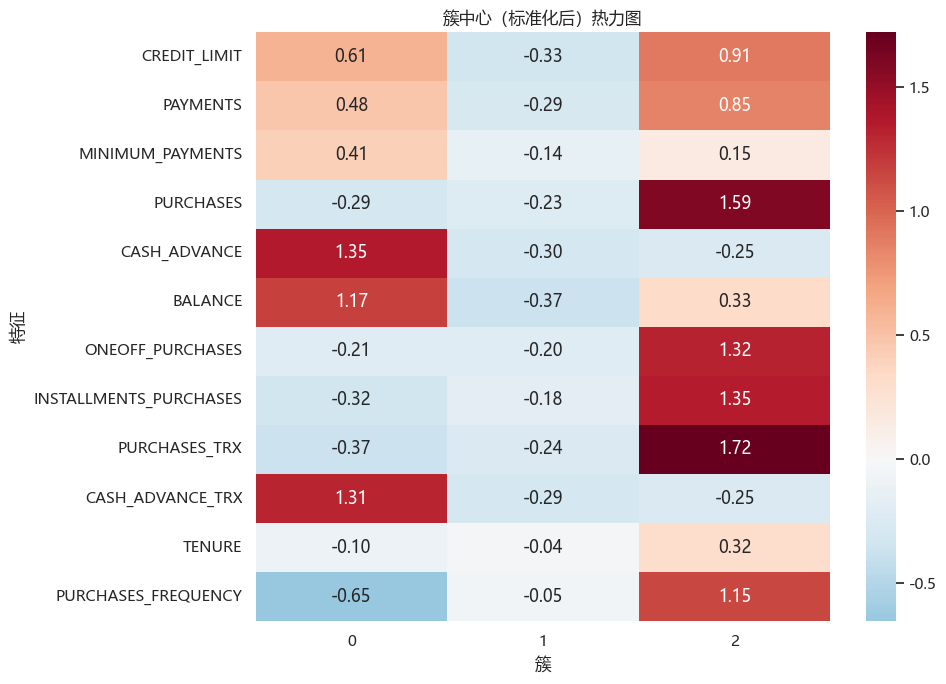


各簇画像解读（基于标准化簇中心的高低值）：
- cluster 0: 高值特征=['CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX']；低值特征=['PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'PRC_FULL_PAYMENT']
- cluster 1: 高值特征=['PRC_FULL_PAYMENT', 'TENURE', 'PURCHASES_INSTALLMENTS_FREQUENCY']；低值特征=['BALANCE', 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT']
- cluster 2: 高值特征=['PURCHASES_TRX', 'PURCHASES', 'ONEOFF_PURCHASES_FREQUENCY']；低值特征=['CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX']


In [42]:
def profile_clusters(result_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
	"""输出每个簇在原始量纲下的均值和样本占比。"""

	size = result_df.groupby("cluster").size().rename("样本数")
	means = result_df.groupby("cluster")[feature_cols].mean()
	profile = size.to_frame().join(means, how="left")
	profile["占比"] = profile["样本数"] / profile["样本数"].sum()
	return profile


feature_cols = X.columns.tolist()
cluster_profile = profile_clusters(result_df, feature_cols)
display(cluster_profile)

centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
centers_scaled.index.name = "cluster"

# 只展示方差较大的前若干特征，避免热力图过于拥挤
top_var_features = X.var().sort_values(ascending=False).head(12).index.tolist()
heatmap_df = centers_scaled[top_var_features].T

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("簇中心（标准化后）热力图")
plt.xlabel("簇")
plt.ylabel("特征")
plt.tight_layout()
plt.show()

print("\n各簇画像解读（基于标准化簇中心的高低值）：")
for cluster_id in centers_scaled.index:
	row = centers_scaled.loc[cluster_id]
	high_features = row.sort_values(ascending=False).head(3).index.tolist()
	low_features = row.sort_values(ascending=True).head(3).index.tolist()
	print(f"- cluster {cluster_id}: 高值特征={high_features}；低值特征={low_features}")


## 9. 各簇人群自然语言画像

聚类 0：预借现金用户 (17.7%)

关键特征： 该群体在 CASH_ADVANCE (1.35)、CASH_ADVANCE_TRX (1.31) 和 BALANCE (1.17) 上具有较高的标准化正值。相反，他们在 PURCHASES_FREQUENCY (-0.65) 和整体 PURCHASES (-0.29) 等消费相关指标上的得分低于平均水平。

概况： 这些客户持有最高的余额，且主要依赖预借现金，而非使用信用卡进行日常消费。他们使用信用卡很可能是为了获取流动性，而非用于常规消费支出。

聚类 1：非活跃客户 (68.7%)

关键特征： 该聚类中所有特征的值均为负数（范围从 -0.04 到 -0.37），意味着他们在所有指标上的表现均低于整体平均水平。

概况： 这些是“休眠”或低参与度的用户。他们的余额、购买量、交易频率和信用额度都很低。他们几乎不使用信用卡进行消费或预借现金。

聚类 2：高额消费用户 (13.5%)

关键特征： 该群体在所有与消费相关的指标上得分极高，包括 PURCHASES_TRX (1.72)、PURCHASES (1.59)、INSTALLMENTS_PURCHASES (1.35)、ONEOFF_PURCHASES (1.32) 和 PURCHASES_FREQUENCY (1.15)。此外，他们还拥有最高的 CREDIT_LIMIT (0.91) 和 PAYMENTS (0.85)。他们的 CASH_ADVANCE (-0.25) 低于平均水平。

概况： 这些是优质或非常活跃的客户，他们经常使用信用卡进行日常支出（包括一次性消费和分期付款）。由于他们的还款额也很高，他们很可能定期偿还大部分账单余额，并避免预借现金。


## 10. 稳定性检查（可选）

K-Means 对初始化敏感。做稳定性检查的原因是：

- 如果不同随机种子下结果波动很大，说明分群结构不稳；
- 不稳定的分群不适合直接用于营销资源分配；
- 通过比较多次结果，可以判断当前 `k` 是否可靠。

我们这里用不同随机种子重复训练，并观察 Silhouette 的波动。


In [43]:
def stability_check(X_scaled: np.ndarray, k: int, seeds: list[int]) -> pd.DataFrame:
	rows = []
	for seed in seeds:
		km = KMeans(n_clusters=k, random_state=seed, n_init=20)
		labels = km.fit_predict(X_scaled)
		rows.append(
			{
				"seed": seed,
				"inertia": km.inertia_,
				"silhouette": silhouette_score(X_scaled, labels),
			}
		)
	return pd.DataFrame(rows)


stability_df = stability_check(X_train_scaled, k=FINAL_K, seeds=[1, 7, 21, 42, 77])
display(stability_df)
print("Silhouette 标准差：", round(stability_df["silhouette"].std(), 4))


,seed,inertia,silhouette
0,1,89415.044638,0.251929
1,7,89415.008319,0.252161
2,21,89415.008319,0.252161
3,42,89415.008319,0.252161
4,77,89415.044638,0.251929


Silhouette 标准差： 0.0001


## 11. 实验结论（撰写参考）

请结合你的运行结果完成总结：

1. **最优簇数是多少？依据是什么？**
   - 说明肘部图的拐点位置；
   - 说明 Silhouette 最高对应的 `k`；
   - 给出最终选用 `k` 及业务解释。

2. **各簇客户行为差异是什么？**
   - 哪些簇“高消费高额度”？
   - 哪些簇“现金预借高、全额还款低”（潜在 `revolvers`）？
   - 哪些簇“高频消费且全额还款”（潜在 `transactors`）？

3. **如何落地到营销/运营策略？**
   - 指出至少 2 条分群差异化策略，并说明预期效果指标。

### 教学结论（参考）

在客户细分任务中，**标准化 + K-Means + 画像解释** 是一个高性价比基线流程。通过将簇中心转译为业务标签，可以把“算法聚类结果”转化为“可执行的银行运营策略”。


## 12. 课堂思考题

1. 如果改用 `MiniBatchKMeans`，在大样本下速度和效果会怎样变化？
2. 如果改用层次聚类或 GMM，得到的人群边界有何差异？
3. 如果加入更多外部特征（收入、地区、渠道），分群解释性会更强吗？
4. 如何在线上验证分群策略确实提升了业务指标（如转化率、ARPU、逾期率）？

---

### 建议运行顺序

1. 先确认 CSV 文件已放入 `data` 目录。
2. 依次运行到第 5 节，观察 `k` 选择结果。
3. 继续运行第 8~9 节，完成画像命名与营销建议。
4. 最后根据图表与表格撰写实验报告。
